# Load libraries

In [88]:
suppressMessages(library("data.table"))
suppressMessages(library("withr"))
suppressMessages(library("ggplot2"))
suppressMessages(library("farver"))
suppressMessages(library("labeling"))
suppressMessages(library("optparse"))
suppressMessages(library("dplyr"))
suppressMessages(library("withr"))
suppressMessages(library("backports"))
suppressMessages(library("broom"))
suppressMessages(library("rstudioapi"))
suppressMessages(library("tzdb"))
suppressMessages(library("svglite"))
suppressMessages(library("ggeasy"))
suppressMessages(library("tidyverse"))
suppressMessages(library("BiocGenerics"))
suppressMessages(library("S4Vectors"))
suppressMessages(library("IRanges"))
suppressMessages(library("GenomeInfoDb"))
suppressMessages(library("GenomicRanges"))
suppressMessages(library("Biobase"))
suppressMessages(library("AnnotationDbi"))
suppressMessages(library("GO.db"))
suppressMessages(library("org.Hs.eg.db"))
suppressMessages(library("ggrepel"))
suppressMessages(library("RColorBrewer"))
suppressMessages(library("svglite"))
suppressMessages(library("cowplot"))
suppressMessages(library("Matrix"))
suppressMessages(library("rtracklayer"))
suppressMessages(library("Biostrings"))
suppressMessages(library("ggrepel"))
suppressMessages(library("ggnewscale"))
suppressMessages(library("splitstackshape"))
suppressMessages(library("viridis"))
suppressMessages(library("viridis"))
suppressMessages(library("ggsci"))
suppressMessages(library("plyr"))
suppressMessages(library("ggupset"))
suppressMessages(library("patchwork"))
suppressMessages(library("ggh4x"))
suppressMessages(library("ComplexHeatmap"))
suppressMessages(library("tidyr"))
suppressMessages(library("circlize"))
suppressMessages(library("grid"))
suppressMessages(library("ggrepel"))
suppressMessages(library("cluster"))
suppressMessages(library("clusterProfiler"))
suppressMessages(library("projectStyleR"))
library(lme4)
library(parallel)
library(UpSetR)

## Load palettes

In [2]:
palettes_path <- system.file("palettes.yaml", package = "projectStyleR")
themes_path <- system.file("themes.yaml", package = "projectStyleR")

In [3]:
palettes <- yaml::read_yaml(palettes_path)
themes <- yaml::read_yaml(themes_path)

In [4]:
available_palettes()
available_themes()

Available palettes:

 - primary

 - vibrant

 - muted_tones

Available themes:

 - default

 - publication



# Read in result files

In [24]:
# --- 1. Locate and parse the new result files ---
results_dir <- "/nfs/team151/mt19/overhaul_classification_factors_with_programs/results_v2/"
result_files <- list.files(results_dir, pattern = "_result\\.tsv$", full.names = TRUE)
cat(length(result_files), "result files found (expect 48)\n")

known_conditions <- c("Across_GWAS_colocalized", "Within_GWAS_colocalized", "Across_full", "Within_full")
known_directions <- c("forward", "reverse", "undirected")
# NOTE: order matters here only in that res_idx takes the FIRST startsWith()
# match - "STRING_experimental" is not a prefix of any other entry, and
# "SCENIC_regulon_same_dataset" is unique too, so this remains unambiguous
# with the 7th resource added.
known_resources <- c("STRING_experimental", "CollecTRI", "Liana", "MEROPS", "POSTAR3",
                      "SCENIC_regulon_activator_same_dataset", "SCENIC_regulon_repressor_same_dataset")

parse_filename_v2 <- function(f) {
  base <- sub("_result\\.tsv$", "", basename(f))

  match_idx <- which(sapply(known_conditions, function(cond) endsWith(base, cond)))
  eqtl_condition <- known_conditions[match_idx[1]]
  remainder <- sub(paste0("_", eqtl_condition, "$"), "", base)

  dir_idx <- which(sapply(known_directions, function(d) endsWith(remainder, d)))
  direction <- known_directions[dir_idx[1]]
  remainder <- sub(paste0("_", direction, "$"), "", remainder)

  res_idx <- which(sapply(known_resources, function(r) startsWith(remainder, r)))
  resource_name <- known_resources[res_idx[1]]
  stringency_label <- sub(paste0("^", resource_name, "_"), "", remainder)

  data.table(file = f, resource_name = resource_name, stringency_label = stringency_label,
             direction = direction, eqtl_condition = eqtl_condition)
}

file_meta <- rbindlist(lapply(result_files, parse_filename_v2))
                          
file_meta<-file_meta[!is.na(resource_name)]
cat("Parsed metadata:\n")
print(file_meta[, .N, by = .(resource_name, stringency_label, direction)])

# --- Relabel the STRING_experimental "lenient" stringency to reflect it's the band, not full lenient ---
file_meta[resource_name == "STRING_experimental" & stringency_label == "lenient",
          stringency_label := "lenient_band_0.1_to_0.4"]

# --- 2. Load and merge the actual result data ---
combined_results <- rbindlist(lapply(seq_len(nrow(file_meta)), function(i) {
  d <- fread(file_meta$file[i])
  d[, `:=`(resource_name = file_meta$resource_name[i],
           stringency_label = file_meta$stringency_label[i],
           direction = file_meta$direction[i],
           eqtl_condition = file_meta$eqtl_condition[i])]
  d
}), fill = TRUE)

cat(nrow(combined_results), "rows in combined_results\n")
str(combined_results)

# --- Sanity check: use the script's OWN is_untestable column directly, verify it agrees with is.na(z_score) ---
stopifnot(all(combined_results$is_untestable == is.na(combined_results$z_score)))
cat("is_untestable column verified consistent with z_score NA pattern.\n")


64 result files found (expect 48)
Parsed metadata:
                            resource_name stringency_label  direction     N
                                   <char>           <char>     <char> <int>
 1:                             CollecTRI           strict    forward     4
 2:                             CollecTRI           strict    reverse     4
 3:                                 Liana          lenient    forward     4
 4:                                 Liana          lenient    reverse     4
 5:                                MEROPS           strict    forward     4
 6:                                MEROPS           strict    reverse     4
 7:                               POSTAR3           strict    forward     4
 8:                               POSTAR3           strict    reverse     4
 9: SCENIC_regulon_activator_same_dataset      single_tier    forward     4
10: SCENIC_regulon_activator_same_dataset      single_tier    reverse     4
11: SCENIC_regulon_repressor_same_dat

# Derived columns (edge_type, graph_type, neg_log10_p, display labels)

In [25]:
print(palettes$vibrant)

$magenta
[1] "#CC79A7"

$green
[1] "#009E73"

$yellow
[1] "#F0E442"

$blue
[1] "#0072B2"

$vermillion
[1] "#D55E00"



In [26]:
# --- 3. Derived columns (edge_type, graph_type, neg_log10_p, display labels) ---
combined_results[, edge_type := sub("_.*", "", eqtl_condition)]
combined_results[, edge_type := factor(edge_type, levels = c("Within", "Across"))]

combined_results[, graph_type := ifelse(grepl("GWAS_colocalized", eqtl_condition), "GWAS_colocalized", "full")]
combined_results[, graph_type := factor(graph_type, levels = c("full", "GWAS_colocalized"))]

combined_results[, neg_log10_p := -log10(p_enrichment)]
combined_results[, fold_enrichment := observed_hits / null_mean]
combined_results[, x_plot := ifelse(is_untestable, 1, fold_enrichment)]

known_resources <- c("STRING_experimental", "CollecTRI", "Liana", "MEROPS", "POSTAR3",
                      "", "SCENIC_regulon_repressor_same_dataset")


resource_display_labels <- c(
  "STRING_experimental"          = "PPI (STRING, experimental)",
  "CollecTRI"                     = "TF-target (CollecTRI)",
  "Liana"                         = "Ligand-Receptor (Liana)",
  "POSTAR3"                       = "RBP-target (POSTAR3)",
  "MEROPS"                        = "Peptidase-substrate (MEROPS)",
  "SCENIC_regulon_activator_same_dataset"   = "activator TF-target (SCENIC)",
  "SCENIC_regulon_repressor_same_dataset"   = "repressor TF-target (SCENIC)"

)
combined_results[, resource_display := resource_display_labels[resource_name]]

resource_colors_display <- resource_colors
names(resource_colors_display) <- resource_display_labels[names(resource_colors)]

# --- Direction display labels, for legend clarity ---
direction_display_labels <- c(
  "forward"    = "Source \u2192 Target",
  "reverse"    = "Target \u2192 Source",
  "undirected" = "Undirected (PPI)"
)
combined_results[, direction_display := direction_display_labels[direction]]


In [27]:
resource_colors <- c(
  "STRING_experimental"          = palettes$vibrant$blue,
  "CollecTRI"                     = palettes$vibrant$vermillion,
  "Liana"                         = palettes$vibrant$green,
  "POSTAR3"                       = palettes$vibrant$magenta,
  "MEROPS"                         = palettes$vibrant$yellow,
  "SCENIC_regulon_activator_same_dataset" = palettes$vibrant$green,
                  "SCENIC_regulon_repressor_same_dataset" = "#000000"
)

In [28]:
head(combined_results)

analysis,direction,condition,observed_hits,null_mean,null_sd,z_score,p_enrichment,is_untestable,resource_name,stringency_label,eqtl_condition,edge_type,graph_type,neg_log10_p,fold_enrichment,x_plot,resource_display,direction_display
<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>,<chr>,<chr>,<chr>,<fct>,<fct>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
CollecTRI,forward,>=2 CollecTRI sub-resources | eQTL: Across_GWAS_colocalized,2,1.7088,1.2112594,0.2404109,0.52944706,FALSE,CollecTRI,strict,Across_GWAS_colocalized,Across,GWAS_colocalized,0.2761775,1.170412,1.170412,TF-target (CollecTRI),Source → Target
CollecTRI,forward,>=2 CollecTRI sub-resources | eQTL: Across_full,16,10.5698,2.7442815,1.9787329,0.03989601,FALSE,CollecTRI,strict,Across_full,Across,full,1.3990705,1.513747,1.513747,TF-target (CollecTRI),Source → Target
CollecTRI,forward,>=2 CollecTRI sub-resources | eQTL: Within_GWAS_colocalized,12,9.1509,2.6458702,1.0768102,0.18698130,FALSE,CollecTRI,strict,Within_GWAS_colocalized,Within,GWAS_colocalized,0.7282018,1.311346,1.311346,TF-target (CollecTRI),Source → Target
CollecTRI,forward,>=2 CollecTRI sub-resources | eQTL: Within_full,72,54.8078,5.7804672,2.9741887,0.00339966,FALSE,CollecTRI,strict,Within_full,Within,full,2.4685645,1.313682,1.313682,TF-target (CollecTRI),Source → Target
CollecTRI,reverse,>=2 CollecTRI sub-resources | eQTL: Across_GWAS_colocalized,0,0.0983,0.3063438,-0.3208814,1.00000000,FALSE,CollecTRI,strict,Across_GWAS_colocalized,Across,GWAS_colocalized,0.0000000,0.000000,0.000000,TF-target (CollecTRI),Target → Source
CollecTRI,reverse,>=2 CollecTRI sub-resources | eQTL: Across_full,7,4.5621,1.9007643,1.2825893,0.15038496,FALSE,CollecTRI,strict,Across_full,Across,full,0.8227956,1.534381,1.534381,TF-target (CollecTRI),Target → Source


In [29]:
colnames(combined_results)

[1] "analysis"          "direction"         "condition"        
 [4] "observed_hits"     "null_mean"         "null_sd"          
 [7] "z_score"           "p_enrichment"      "is_untestable"    
[10] "resource_name"     "stringency_label"  "eqtl_condition"   
[13] "edge_type"         "graph_type"        "neg_log10_p"      
[16] "fold_enrichment"   "x_plot"            "resource_display" 
[19] "direction_display"

# Multiple testing correction

In [30]:
# --- Re-run correction fresh ---
n_total    <- nrow(combined_results)
n_testable <- sum(!combined_results$is_untestable)

combined_results[, p_adj_BH := NA_real_]
combined_results[is_untestable == FALSE, p_adj_BH := p.adjust(p_enrichment, method = "BH")]

combined_results[, p_adj_bonferroni := NA_real_]
combined_results[is_untestable == FALSE, p_adj_bonferroni := pmin(p_enrichment * n_testable, 1)]

combined_results[, sig_BH_05 := !is.na(p_adj_BH) & p_adj_BH < 0.05]
combined_results[, sig_bonferroni_05 := !is.na(p_adj_bonferroni) & p_adj_bonferroni < 0.05]

# --- Explicit verification the columns actually exist before trusting any count ---
stopifnot(all(c("p_adj_BH", "p_adj_bonferroni", "sig_BH_05", "sig_bonferroni_05") %in% colnames(combined_results)))
cat("Correction columns confirmed present.\n")

cat("Testable:", n_testable, "| Sig BH<0.05:", sum(combined_results$sig_BH_05, na.rm = TRUE),
    "| Sig Bonferroni<0.05:", sum(combined_results$sig_bonferroni_05, na.rm = TRUE), "\n")

print(combined_results[order(p_enrichment)][,
  .(resource_display, stringency_label, direction, eqtl_condition,
    observed_hits, null_mean, z_score, p_enrichment, p_adj_BH, p_adj_bonferroni,
    sig_BH_05, sig_bonferroni_05, is_untestable)])

Correction columns confirmed present.
Testable: 49 | Sig BH<0.05: 8 | Sig Bonferroni<0.05: 5 
                resource_display        stringency_label  direction
                          <char>                  <char>     <char>
 1: activator TF-target (SCENIC)             single_tier    forward
 2: activator TF-target (SCENIC)             single_tier    forward
 3: activator TF-target (SCENIC)             single_tier    forward
 4: activator TF-target (SCENIC)             single_tier    reverse
 5:   PPI (STRING, experimental) lenient_band_0.1_to_0.4 undirected
 6:   PPI (STRING, experimental)                  strict undirected
 7:        TF-target (CollecTRI)                  strict    forward
 8:   PPI (STRING, experimental) lenient_band_0.1_to_0.4 undirected
 9:   PPI (STRING, experimental)                  strict undirected
10:      Ligand-Receptor (Liana)                 lenient    forward
11: activator TF-target (SCENIC)             single_tier    reverse
12:        TF-target (

## Compute CI

In [31]:
# --- Re-run CI computation, confirm columns exist before plotting ---
compute_poisson_ci <- function(obs, null_mean, conf_level = 0.95) {
  ci <- poisson.test(obs, conf.level = conf_level)$conf.int
  data.table(fold_ci_low = ci[1] / null_mean, fold_ci_high = ci[2] / null_mean)
}

ci_results <- rbindlist(lapply(seq_len(nrow(combined_results)), function(i) {
  row <- combined_results[i]
  if (row$is_untestable || row$null_mean == 0) {
    data.table(fold_ci_low = NA_real_, fold_ci_high = NA_real_)
  } else {
    compute_poisson_ci(row$observed_hits, row$null_mean)
  }
}))

combined_results <- cbind(combined_results, ci_results)

stopifnot(all(c("fold_ci_low", "fold_ci_high") %in% colnames(combined_results)))
cat("CI columns confirmed present.\n")

CI columns confirmed present.


## Plot #1

In [32]:
combined_results[, row_label := paste(resource_display, direction_display, sep = " | ")]

Warning message in scale_x_log10():
“log-10 transformation introduced infinite values.”
Warning message in scale_x_log10():
“log-10 transformation introduced infinite values.”
Warning message in scale_x_log10():
“log-10 transformation introduced infinite values.”


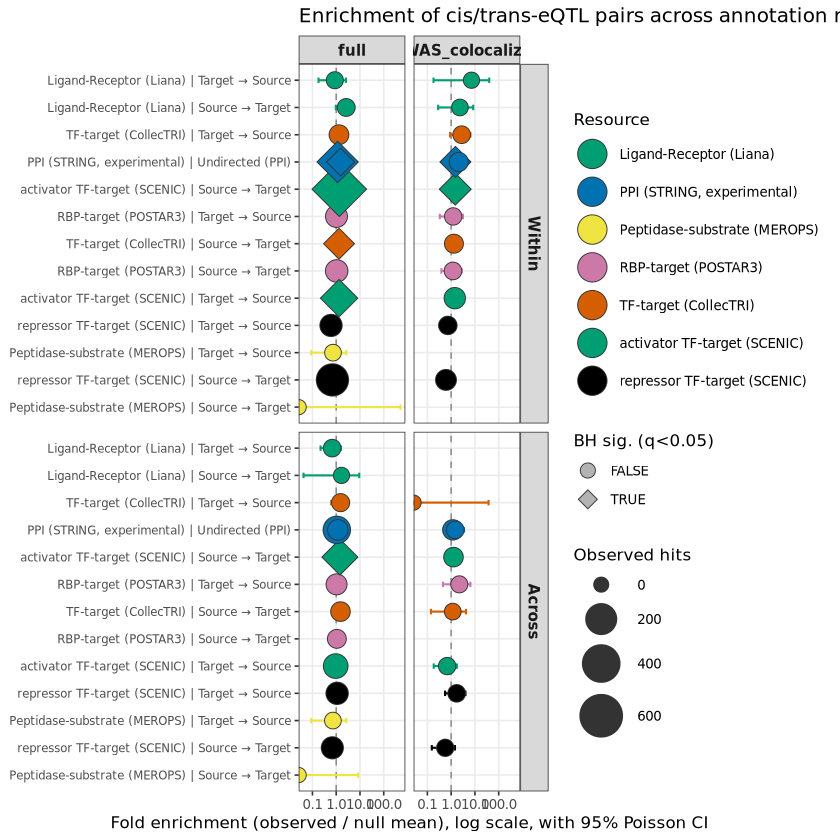

In [33]:
forest_plot <- ggplot(combined_results[is_untestable == FALSE],
                       aes(x = fold_enrichment, y = reorder(row_label, fold_enrichment))) +
  geom_vline(xintercept = 1, linetype = "dashed", color = "grey40", alpha = 0.7) +
  geom_errorbar(aes(xmin = fold_ci_low, xmax = fold_ci_high, color = resource_display),
                orientation = "y", width = 0.2, linewidth = 0.6) +
  geom_point(aes(size = observed_hits, fill = resource_display, shape = sig_BH_05),
             color = "grey20", stroke = 0.4) +
  scale_shape_manual(values = c("TRUE" = 23, "FALSE" = 21), name = "BH sig. (q<0.05)") +
  scale_fill_manual(values = resource_colors_display, name = "Resource") +
  scale_color_manual(values = resource_colors_display, guide = "none") +
  scale_size_continuous(name = "Observed hits", range = c(4, 12)) +
  guides(
    fill  = guide_legend(override.aes = list(size = 8, shape = 21, colour = "grey20"), order = 1),
    shape = guide_legend(override.aes = list(size = 4, fill = "grey70"), order = 2)
  ) +
  scale_x_log10() +
  facet_grid(rows = vars(edge_type), cols = vars(graph_type), scales = "free_y", space = "free_y") +
  labs(
    x = "Fold enrichment (observed / null mean), log scale, with 95% Poisson CI",
    y = NULL,
    title = "Enrichment of cis/trans-eQTL pairs across annotation resources"
  ) +
  theme_bw(base_size = 10) +
  theme(
    axis.text.y = element_text(size = 7),
    strip.text = element_text(size = 9, face = "bold"),
    panel.grid.minor = element_blank()
  )

print(forest_plot)

### SAVE

In [34]:
# --- Create output directory and save in all three formats ---
graph_dir <- "/nfs/team151/mt19/overhaul_classification_factors_with_programs/graphs/"
dir.create(graph_dir, recursive = TRUE, showWarnings = FALSE)

ggsave(filename = paste0(graph_dir, "enrichment_forest_plot.pdf"), plot = forest_plot,
       device = "pdf", width = 10, height = 8)
ggsave(filename = paste0(graph_dir, "enrichment_forest_plot.png"), plot = forest_plot,
       device = "png", width = 10, height = 8, dpi = 300, bg="white")
ggsave(filename = paste0(graph_dir, "enrichment_forest_plot.svg"), plot = forest_plot,
       device = "svg", width = 10, height = 8)

cat("Saved to", graph_dir, "\n")
list.files(graph_dir)

Warning message in scale_x_log10():
“log-10 transformation introduced infinite values.”
Warning message in scale_x_log10():
“log-10 transformation introduced infinite values.”
Warning message in scale_x_log10():
“log-10 transformation introduced infinite values.”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'Peptidase-substrate (MEROPS) | Source → Target' in 'mbcsToSbcs': -> substituted for → (U+2192)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'repressor TF-target (SCENIC) | Source → Target' in 'mbcsToSbcs': -> substituted for → (U+2192)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'Peptidase-substrate (MEROPS) | Target → Source' in 'mbcsToSbcs': -> substituted for → (U+2192)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'repressor TF-target (SCENIC) | Target → Source' in 'mbcsToSbcs': -> substituted for 

Saved to /nfs/team151/mt19/overhaul_classification_factors_with_programs/graphs/ 


[1] "enrichment_forest_plot.pdf"    "enrichment_forest_plot.png"   
 [3] "enrichment_forest_plot.svg"    "enrichment_forest_plot_v3.pdf"
 [5] "enrichment_forest_plot_v3.png" "enrichment_forest_plot_v3.svg"
 [7] "enrichment_forest_plot_v5.pdf" "enrichment_forest_plot_v5.png"
 [9] "enrichment_forest_plot_v5.svg" "enrichment_forest_plot_v6.pdf"
[11] "enrichment_forest_plot_v6.png" "enrichment_forest_plot_v6.svg"
[13] "enrichment_forest_plot_v7.pdf" "enrichment_forest_plot_v7.png"
[15] "enrichment_forest_plot_v7.svg" "enrichment_forest_plot_v8.pdf"
[17] "enrichment_forest_plot_v8.png" "enrichment_forest_plot_v8.svg"
[19] "enrichment_forest_plot_v9.pdf" "enrichment_forest_plot_v9.png"
[21] "enrichment_forest_plot_v9.svg"

### Refined plot

In [35]:
# --- Rebuild row_label to include stringency, THEN build the ordering key ---
combined_results[, row_label := paste(resource_display, stringency_label, direction_display, sep = " | ")]



resource_order <- c(  
  "TF-target (CollecTRI)",
  "activator TF-target (SCENIC)",
   "repressor TF-target (SCENIC)", 
    "PPI (STRING, experimental)",
  "Ligand-Receptor (Liana)",
  "RBP-target (POSTAR3)",
  "Peptidase-substrate (MEROPS)"
)
direction_order <- c("Source \u2192 Target", "Target \u2192 Source", "Undirected (PPI)")

row_order_key <- unique(combined_results[is_untestable == FALSE,
                                          .(row_label, resource_display, stringency_label, direction_display)])

row_order_key[, resource_rank := match(resource_display, resource_order)]
row_order_key[, direction_rank := match(direction_display, direction_order)]
row_order_key[, stringency_rank := fifelse(stringency_label == "strict", 1,
                                    fifelse(stringency_label == "lenient", 2,
                                    fifelse(stringency_label == "lenient_band_0.1_to_0.4", 3, 4)))]

row_order_key <- row_order_key[order(resource_rank, stringency_rank, direction_rank)]

stopifnot(all(!is.na(row_order_key$resource_rank)))
stopifnot(!any(duplicated(row_order_key$row_label)))  # explicit check this time, catches the exact bug you just hit

combined_results[, row_label := factor(row_label, levels = row_order_key$row_label)]

print(row_order_key[, .(row_label, resource_display, stringency_label, direction_display)])

                                                                  row_label
                                                                     <char>
 1:                        TF-target (CollecTRI) | strict | Source → Target
 2:                        TF-target (CollecTRI) | strict | Target → Source
 3:            activator TF-target (SCENIC) | single_tier | Source → Target
 4:            activator TF-target (SCENIC) | single_tier | Target → Source
 5:            repressor TF-target (SCENIC) | single_tier | Source → Target
 6:            repressor TF-target (SCENIC) | single_tier | Target → Source
 7:                  PPI (STRING, experimental) | strict | Undirected (PPI)
 8: PPI (STRING, experimental) | lenient_band_0.1_to_0.4 | Undirected (PPI)
 9:                     Ligand-Receptor (Liana) | lenient | Source → Target
10:                     Ligand-Receptor (Liana) | lenient | Target → Source
11:                         RBP-target (POSTAR3) | strict | Source → Target
12:         

Warning message in scale_x_log10(breaks = c(0.1, 0.25, 0.5, 1, 2, 4, 8, 16), labels = scales::label_number(accuracy = 0.01)):
“log-10 transformation introduced infinite values.”
Warning message in scale_x_log10(breaks = c(0.1, 0.25, 0.5, 1, 2, 4, 8, 16), labels = scales::label_number(accuracy = 0.01)):
“log-10 transformation introduced infinite values.”
Warning message in scale_x_log10(breaks = c(0.1, 0.25, 0.5, 1, 2, 4, 8, 16), labels = scales::label_number(accuracy = 0.01)):
“log-10 transformation introduced infinite values.”


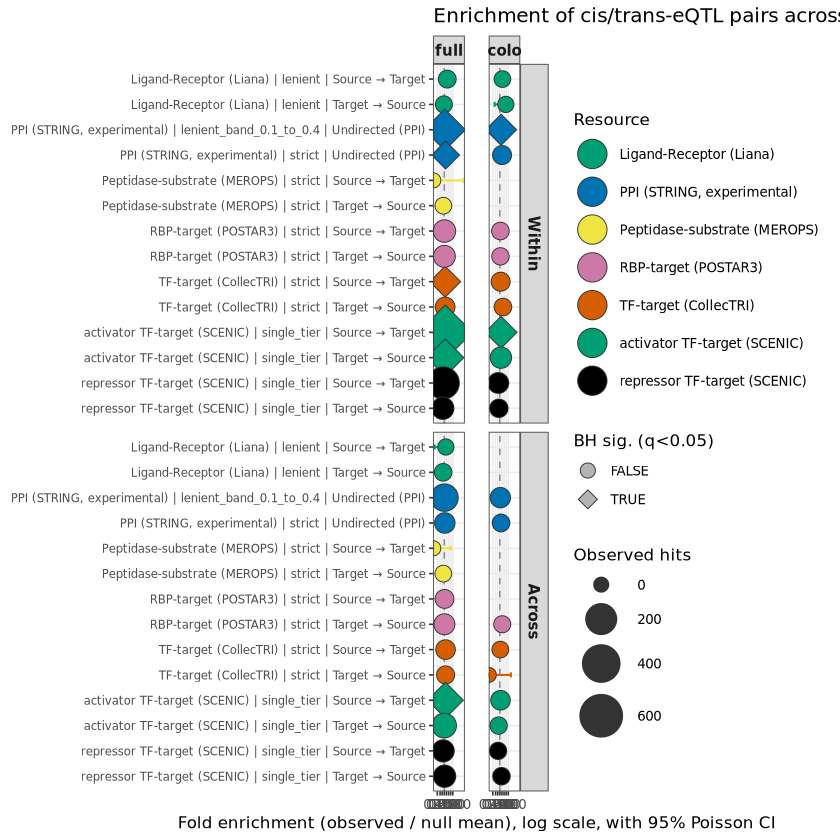

In [36]:
# --- Row label now includes stringency, so strict vs lenient-band STRING get separate rows ---
combined_results[, row_label := paste(resource_display, stringency_label, direction_display, sep = " | ")]

forest_plot_v3 <- ggplot(combined_results[is_untestable == FALSE],
                          aes(x = fold_enrichment, y = row_label)) +
  geom_vline(xintercept = 1, linetype = "dashed", color = "grey40", alpha = 0.7) +
  geom_errorbar(aes(xmin = fold_ci_low, xmax = fold_ci_high, color = resource_display),
                orientation = "y", width = 0.2, linewidth = 0.6) +
  geom_point(aes(size = observed_hits, fill = resource_display, shape = sig_BH_05),
             color = "grey20", stroke = 0.4) +
  scale_shape_manual(values = c("TRUE" = 23, "FALSE" = 21), name = "BH sig. (q<0.05)") +
  scale_fill_manual(values = resource_colors_display, name = "Resource") +
  scale_color_manual(values = resource_colors_display, guide = "none") +
  scale_size_continuous(name = "Observed hits", range = c(4, 12)) +
  guides(
    fill  = guide_legend(override.aes = list(size = 8, shape = 21, colour = "grey20"), order = 1),
    shape = guide_legend(override.aes = list(size = 4, fill = "grey70"), order = 2)
  ) +
  scale_x_log10(breaks = c(0.1, 0.25, 0.5, 1, 2, 4, 8, 16),
                labels = scales::label_number(accuracy = 0.01)) +
  scale_y_discrete(limits = rev) +
  facet_grid(rows = vars(edge_type), cols = vars(graph_type), scales = "free_y", space = "free_y") +
  labs(
    x = "Fold enrichment (observed / null mean), log scale, with 95% Poisson CI",
    y = NULL,
    title = "Enrichment of cis/trans-eQTL pairs across annotation resources"
  ) +
  theme_bw(base_size = 10) +
  theme(
    axis.text.y = element_text(size = 7),
    strip.text = element_text(size = 9, face = "bold"),
    panel.grid.minor = element_blank(),
    panel.spacing.x = unit(1, "lines")
  )

print(forest_plot_v3)

In [37]:
ggsave(filename = paste0(graph_dir, "enrichment_forest_plot_v3.pdf"), plot = forest_plot_v3,
       device = "pdf", width = 16, height = 8)
ggsave(filename = paste0(graph_dir, "enrichment_forest_plot_v3.png"), plot = forest_plot_v3,
       device = "png", width = 16, height = 8, dpi = 300, bg="white")
ggsave(filename = paste0(graph_dir, "enrichment_forest_plot_v3.svg"), plot = forest_plot_v3,
       device = "svg", width = 16, height = 8)

cat("Saved to", graph_dir, "\n")
list.files(graph_dir, pattern = "v3")

Warning message in scale_x_log10(breaks = c(0.1, 0.25, 0.5, 1, 2, 4, 8, 16), labels = scales::label_number(accuracy = 0.01)):
“log-10 transformation introduced infinite values.”
Warning message in scale_x_log10(breaks = c(0.1, 0.25, 0.5, 1, 2, 4, 8, 16), labels = scales::label_number(accuracy = 0.01)):
“log-10 transformation introduced infinite values.”
Warning message in scale_x_log10(breaks = c(0.1, 0.25, 0.5, 1, 2, 4, 8, 16), labels = scales::label_number(accuracy = 0.01)):
“log-10 transformation introduced infinite values.”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'repressor TF-target (SCENIC) | single_tier | Target → Source' in 'mbcsToSbcs': -> substituted for → (U+2192)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'repressor TF-target (SCENIC) | single_tier | Source → Target' in 'mbcsToSbcs': -> substituted for → (U+2192)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x

Saved to /nfs/team151/mt19/overhaul_classification_factors_with_programs/graphs/ 


[1] "enrichment_forest_plot_v3.pdf" "enrichment_forest_plot_v3.png"
[3] "enrichment_forest_plot_v3.svg"

## Refined plot 2

In [38]:
# --- Build display stringency label per resource ---
# For PPI (STRING, experimental): stringency becomes the actual score threshold.
# For every other resource: drop the stringency segment entirely (only one
# stringency per resource will appear in the methods, so it's redundant here).

combined_results[, stringency_display := fifelse(
  resource_display == "PPI (STRING, experimental)",
  fifelse(stringency_label == "strict", "score \u2265 0.4",
  fifelse(stringency_label == "lenient_band_0.1_to_0.4", "0.1 < score \u2264 0.4", stringency_label)),
  NA_character_   # drop for all other resources
)]

# --- Replace " | " separator with a newline for multi-line y-axis labels ---
combined_results[, row_label := fifelse(
  is.na(stringency_display),
  paste(resource_display, direction_display, sep = "\n"),
  paste(resource_display, stringency_display, direction_display, sep = "\n")
)]

# --- Rebuild the ordering on the new row_label text (same logic as before) ---
row_order_key <- unique(combined_results[is_untestable == FALSE,
                                          .(row_label, resource_display, stringency_label, direction_display)])

row_order_key[, resource_rank := match(resource_display, resource_order)]
row_order_key[, direction_rank := match(direction_display, direction_order)]
row_order_key[, stringency_rank := fifelse(stringency_label == "strict", 1,
                                    fifelse(stringency_label == "lenient", 2,
                                    fifelse(stringency_label == "lenient_band_0.1_to_0.4", 3, 4)))]

row_order_key <- row_order_key[order(resource_rank, stringency_rank, direction_rank)]
stopifnot(all(!is.na(row_order_key$resource_rank)))

combined_results[, row_label := factor(row_label, levels = row_order_key$row_label)]

print(row_order_key[, .(row_label)])

                                                          row_label
                                                             <char>
 1:                          TF-target (CollecTRI)\nSource → Target
 2:                          TF-target (CollecTRI)\nTarget → Source
 3:                   activator TF-target (SCENIC)\nSource → Target
 4:                   activator TF-target (SCENIC)\nTarget → Source
 5:                   repressor TF-target (SCENIC)\nSource → Target
 6:                   repressor TF-target (SCENIC)\nTarget → Source
 7:       PPI (STRING, experimental)\nscore ≥ 0.4\nUndirected (PPI)
 8: PPI (STRING, experimental)\n0.1 < score ≤ 0.4\nUndirected (PPI)
 9:                        Ligand-Receptor (Liana)\nSource → Target
10:                        Ligand-Receptor (Liana)\nTarget → Source
11:                           RBP-target (POSTAR3)\nSource → Target
12:                           RBP-target (POSTAR3)\nTarget → Source
13:                   Peptidase-substrate (MEROP

Warning message in scale_x_log10(breaks = c(0.1, 0.25, 0.5, 1, 2, 4, 8, 16), labels = scales::label_number(accuracy = 0.01)):
“log-10 transformation introduced infinite values.”
Warning message in scale_x_log10(breaks = c(0.1, 0.25, 0.5, 1, 2, 4, 8, 16), labels = scales::label_number(accuracy = 0.01)):
“log-10 transformation introduced infinite values.”
Warning message in scale_x_log10(breaks = c(0.1, 0.25, 0.5, 1, 2, 4, 8, 16), labels = scales::label_number(accuracy = 0.01)):
“log-10 transformation introduced infinite values.”


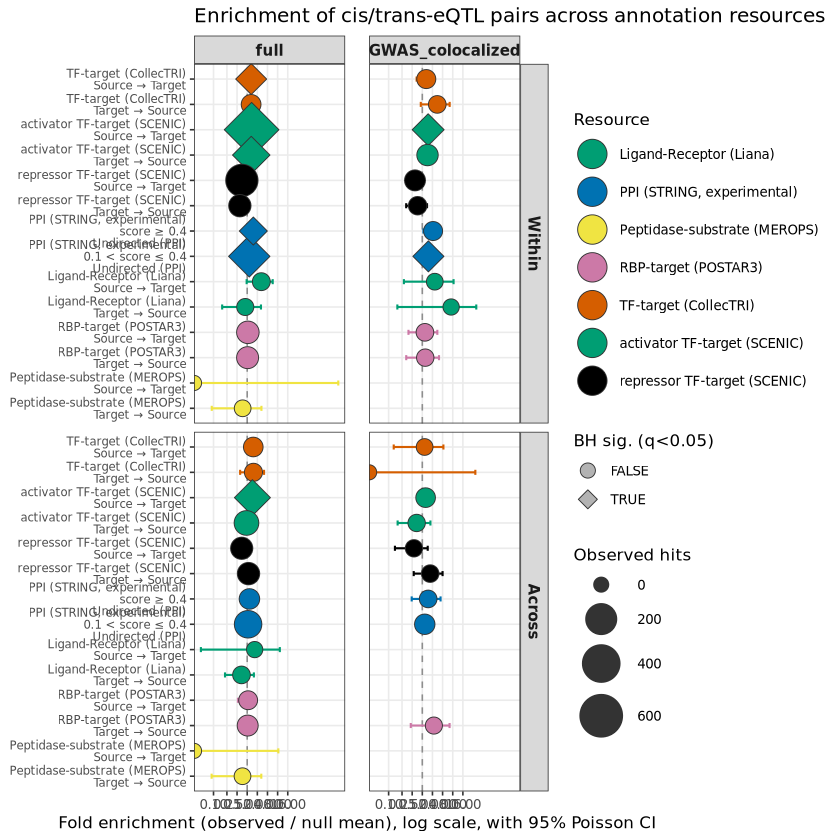

In [39]:
forest_plot_v5 <- ggplot(combined_results[is_untestable == FALSE],
                          aes(x = fold_enrichment, y = row_label)) +
  geom_vline(xintercept = 1, linetype = "dashed", color = "grey40", alpha = 0.7) +
  geom_errorbar(aes(xmin = fold_ci_low, xmax = fold_ci_high, color = resource_display),
                orientation = "y", width = 0.2, linewidth = 0.6) +
  geom_point(aes(size = observed_hits, fill = resource_display, shape = sig_BH_05),
             color = "grey20", stroke = 0.4) +
  scale_shape_manual(values = c("TRUE" = 23, "FALSE" = 21), name = "BH sig. (q<0.05)") +
  scale_fill_manual(values = resource_colors_display, name = "Resource") +
  scale_color_manual(values = resource_colors_display, guide = "none") +
  scale_size_continuous(name = "Observed hits", range = c(4, 12)) +
  guides(
    fill  = guide_legend(override.aes = list(size = 8, shape = 21, colour = "grey20"), order = 1),
    shape = guide_legend(override.aes = list(size = 4, fill = "grey70"), order = 2)
  ) +
  scale_x_log10(breaks = c(0.1, 0.25, 0.5, 1, 2, 4, 8, 16),
                labels = scales::label_number(accuracy = 0.01)) +
  scale_y_discrete(limits = rev) +
  facet_grid(rows = vars(edge_type), cols = vars(graph_type), scales = "free_y", space = "free_y") +
  labs(
    x = "Fold enrichment (observed / null mean), log scale, with 95% Poisson CI",
    y = NULL,
    title = "Enrichment of cis/trans-eQTL pairs across annotation resources"
  ) +
  theme_bw(base_size = 10) +
  theme(
    axis.text.y = element_text(size = 7, lineheight = 0.85),
    strip.text = element_text(size = 9, face = "bold"),
    panel.grid.minor = element_blank(),
    panel.spacing.x = unit(1, "lines")
  )

print(forest_plot_v5)

## SAVE

In [40]:
ggsave(filename = paste0(graph_dir, "enrichment_forest_plot_v5.pdf"), plot = forest_plot_v5,
       device = "pdf", width = 16, height = 9)
ggsave(filename = paste0(graph_dir, "enrichment_forest_plot_v5.png"), plot = forest_plot_v5,
       device = "png", width = 16, height = 9, dpi = 300, bg="white")
ggsave(filename = paste0(graph_dir, "enrichment_forest_plot_v5.svg"), plot = forest_plot_v5,
       device = "svg", width = 16, height = 9)

cat("Saved to", graph_dir, "\n")
list.files(graph_dir, pattern = "v5")

Warning message in scale_x_log10(breaks = c(0.1, 0.25, 0.5, 1, 2, 4, 8, 16), labels = scales::label_number(accuracy = 0.01)):
“log-10 transformation introduced infinite values.”
Warning message in scale_x_log10(breaks = c(0.1, 0.25, 0.5, 1, 2, 4, 8, 16), labels = scales::label_number(accuracy = 0.01)):
“log-10 transformation introduced infinite values.”
Warning message in scale_x_log10(breaks = c(0.1, 0.25, 0.5, 1, 2, 4, 8, 16), labels = scales::label_number(accuracy = 0.01)):
“log-10 transformation introduced infinite values.”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'Target → Source' in 'mbcsToSbcs': -> substituted for → (U+2192)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'Source → Target' in 'mbcsToSbcs': -> substituted for → (U+2192)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'Target → Source' in 'mbcsToSbcs': -> substituted for → (U+2192)

Saved to /nfs/team151/mt19/overhaul_classification_factors_with_programs/graphs/ 


[1] "enrichment_forest_plot_v5.pdf" "enrichment_forest_plot_v5.png"
[3] "enrichment_forest_plot_v5.svg"

# refined 3

In [41]:
# --- Confirm which plotted points have observed_hits == 0 ---
zero_hit_rows <- combined_results[is_untestable == FALSE & observed_hits == 0]
print(zero_hit_rows[, .(resource_display, direction, eqtl_condition, observed_hits, null_mean, fold_enrichment, fold_ci_low, fold_ci_high)])

               resource_display direction          eqtl_condition observed_hits
                         <char>    <char>                  <char>         <int>
1:        TF-target (CollecTRI)   reverse Across_GWAS_colocalized             0
2: Peptidase-substrate (MEROPS)   forward             Across_full             0
3: Peptidase-substrate (MEROPS)   forward             Within_full             0
   null_mean fold_enrichment fold_ci_low fold_ci_high
       <num>           <num>       <num>        <num>
1:    0.0983               0           0    37.526749
2:    0.4388               0           0     8.406744
3:    0.0073               0           0   505.325953


In [42]:
# --- Explicit flag for zero-hit rows, handled separately from the log-scale mapping ---
combined_results[, is_zero_hit := is_untestable == FALSE & observed_hits == 0]

# For plotting position only: zero-hit rows get placed at the lower x-limit,
# with a distinct shape/label rather than pretending they have a real fold value
x_axis_floor <- 0.05  # just below the smallest real non-zero fold value on the log scale

combined_results[, x_plot_final := fifelse(is_zero_hit, x_axis_floor, fold_enrichment)]
combined_results[, ci_low_plot  := fifelse(is_zero_hit, NA_real_, fold_ci_low)]   # no CI whisker for these
combined_results[, ci_high_plot := fifelse(is_zero_hit, NA_real_, fold_ci_high)]

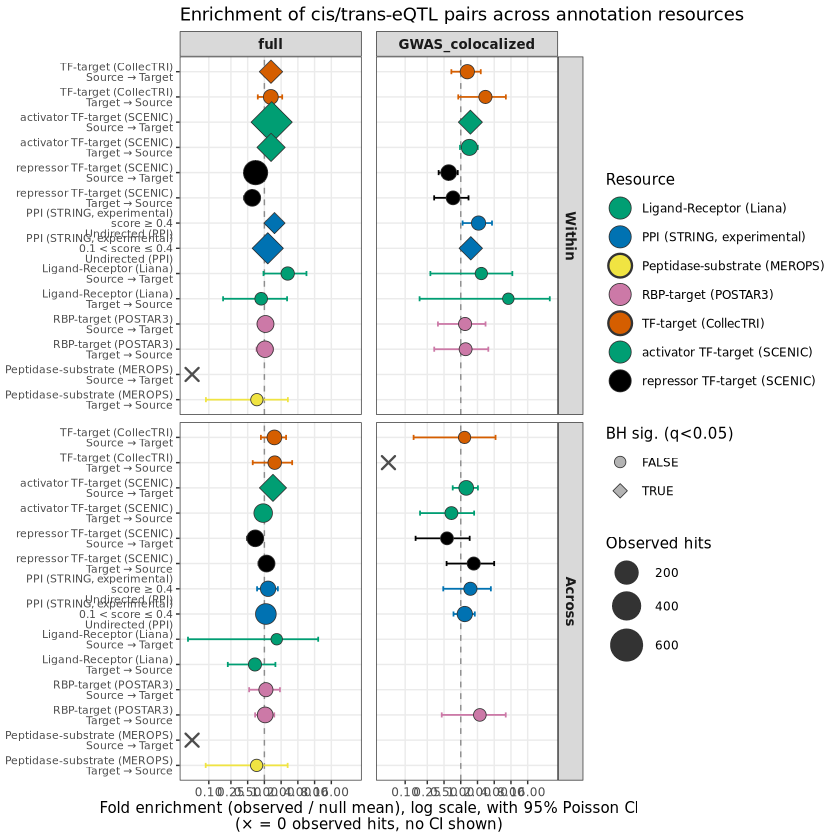

In [43]:
forest_plot_v6 <- ggplot(combined_results[is_untestable == FALSE],
                          aes(x = x_plot_final, y = row_label)) +
  geom_vline(xintercept = 1, linetype = "dashed", color = "grey40", alpha = 0.7) +
  geom_errorbar(aes(xmin = ci_low_plot, xmax = ci_high_plot, color = resource_display),
                orientation = "y", width = 0.2, linewidth = 0.5, na.rm = TRUE) +
  geom_point(
    data = combined_results[is_untestable == FALSE & is_zero_hit == FALSE],
    aes(size = observed_hits, fill = resource_display, shape = sig_BH_05),
    color = "grey20", stroke = 0.35
  ) +
  geom_point(
    data = combined_results[is_untestable == FALSE & is_zero_hit == TRUE],
    aes(fill = resource_display), shape = 4, size = 3, color = "grey30", stroke = 1
  ) +
  scale_shape_manual(values = c("TRUE" = 23, "FALSE" = 21), name = "BH sig. (q<0.05)") +
  scale_fill_manual(values = resource_colors_display, name = "Resource") +
  scale_color_manual(values = resource_colors_display, guide = "none") +
  scale_size_continuous(name = "Observed hits", range = c(3, 9)) +
  guides(
    fill  = guide_legend(override.aes = list(size = 6, shape = 21, colour = "grey20"), order = 1),
    shape = guide_legend(override.aes = list(size = 3, fill = "grey70"), order = 2)
  ) +
  scale_x_log10(breaks = c(0.1, 0.25, 0.5, 1, 2, 4, 8, 16),
                labels = scales::label_number(accuracy = 0.01)) +
  scale_y_discrete(limits = rev) +
  facet_grid(rows = vars(edge_type), cols = vars(graph_type), scales = "free_y", space = "free_y") +
  labs(
    x = "Fold enrichment (observed / null mean), log scale, with 95% Poisson CI\n(\u00d7 = 0 observed hits, no CI shown)",
    y = NULL,
    title = "Enrichment of cis/trans-eQTL pairs across annotation resources"
  ) +
  theme_bw(base_size = 9) +
  theme(
    axis.text.y = element_text(size = 6.5, lineheight = 0.8),
    strip.text = element_text(size = 8, face = "bold"),
    panel.grid.minor = element_blank(),
    panel.spacing.x = unit(0.6, "lines")
  )

print(forest_plot_v6)

In [44]:
ggsave(filename = paste0(graph_dir, "enrichment_forest_plot_v6.pdf"), plot = forest_plot_v6,
       device = "pdf", width = 12, height = 9)
ggsave(filename = paste0(graph_dir, "enrichment_forest_plot_v6.png"), plot = forest_plot_v6,
       device = "png", width = 12, height = 9, dpi = 300, bg="white")
ggsave(filename = paste0(graph_dir, "enrichment_forest_plot_v6.svg"), plot = forest_plot_v6,
       device = "svg", width = 12, height = 9)

cat("Saved to", graph_dir, "\n")
list.files(graph_dir, pattern = "v6")

Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'Target → Source' in 'mbcsToSbcs': -> substituted for → (U+2192)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'Source → Target' in 'mbcsToSbcs': -> substituted for → (U+2192)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'Target → Source' in 'mbcsToSbcs': -> substituted for → (U+2192)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'Source → Target' in 'mbcsToSbcs': -> substituted for → (U+2192)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'Target → Source' in 'mbcsToSbcs': -> substituted for → (U+2192)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'Source → Target' in 'mbcsToSbcs': -> substituted for → (U+2192)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x

Saved to /nfs/team151/mt19/overhaul_classification_factors_with_programs/graphs/ 


[1] "enrichment_forest_plot_v6.pdf" "enrichment_forest_plot_v6.png"
[3] "enrichment_forest_plot_v6.svg"

# refined 4

In [45]:
# --- Relabel direction display: Source -> cis-eQTL, Target -> trans-eQTL ---
direction_display_labels <- c(
  "forward"    = "cis-eQTL \u2192 trans-eQTL",
  "reverse"    = "trans-eQTL \u2192 cis-eQTL",
  "undirected" = "Undirected (PPI)"
)
combined_results[, direction_display := direction_display_labels[direction]]

direction_order <- c("cis-eQTL \u2192 trans-eQTL", "trans-eQTL \u2192 cis-eQTL", "Undirected (PPI)")

# --- Rebuild row_label with the new direction text ---
combined_results[, row_label := fifelse(
  is.na(stringency_display),
  paste(resource_display, direction_display, sep = "\n"),
  paste(resource_display, stringency_display, direction_display, sep = "\n")
)]

# --- Rebuild ordering on the new row_label text ---
row_order_key <- unique(combined_results[is_untestable == FALSE,
                                          .(row_label, resource_display, stringency_label, direction_display)])

row_order_key[, resource_rank := match(resource_display, resource_order)]
row_order_key[, direction_rank := match(direction_display, direction_order)]
row_order_key[, stringency_rank := fifelse(stringency_label == "strict", 1,
                                    fifelse(stringency_label == "lenient", 2,
                                    fifelse(stringency_label == "lenient_band_0.1_to_0.4", 3, 4)))]

row_order_key <- row_order_key[order(resource_rank, stringency_rank, direction_rank)]
stopifnot(all(!is.na(row_order_key$resource_rank)))

combined_results[, row_label := factor(row_label, levels = row_order_key$row_label)]

print(row_order_key[, .(row_label)])

                                                          row_label
                                                             <char>
 1:                    TF-target (CollecTRI)\ncis-eQTL → trans-eQTL
 2:                    TF-target (CollecTRI)\ntrans-eQTL → cis-eQTL
 3:             activator TF-target (SCENIC)\ncis-eQTL → trans-eQTL
 4:             activator TF-target (SCENIC)\ntrans-eQTL → cis-eQTL
 5:             repressor TF-target (SCENIC)\ncis-eQTL → trans-eQTL
 6:             repressor TF-target (SCENIC)\ntrans-eQTL → cis-eQTL
 7:       PPI (STRING, experimental)\nscore ≥ 0.4\nUndirected (PPI)
 8: PPI (STRING, experimental)\n0.1 < score ≤ 0.4\nUndirected (PPI)
 9:                  Ligand-Receptor (Liana)\ncis-eQTL → trans-eQTL
10:                  Ligand-Receptor (Liana)\ntrans-eQTL → cis-eQTL
11:                     RBP-target (POSTAR3)\ncis-eQTL → trans-eQTL
12:                     RBP-target (POSTAR3)\ntrans-eQTL → cis-eQTL
13:             Peptidase-substrate (MEROPS)\nci

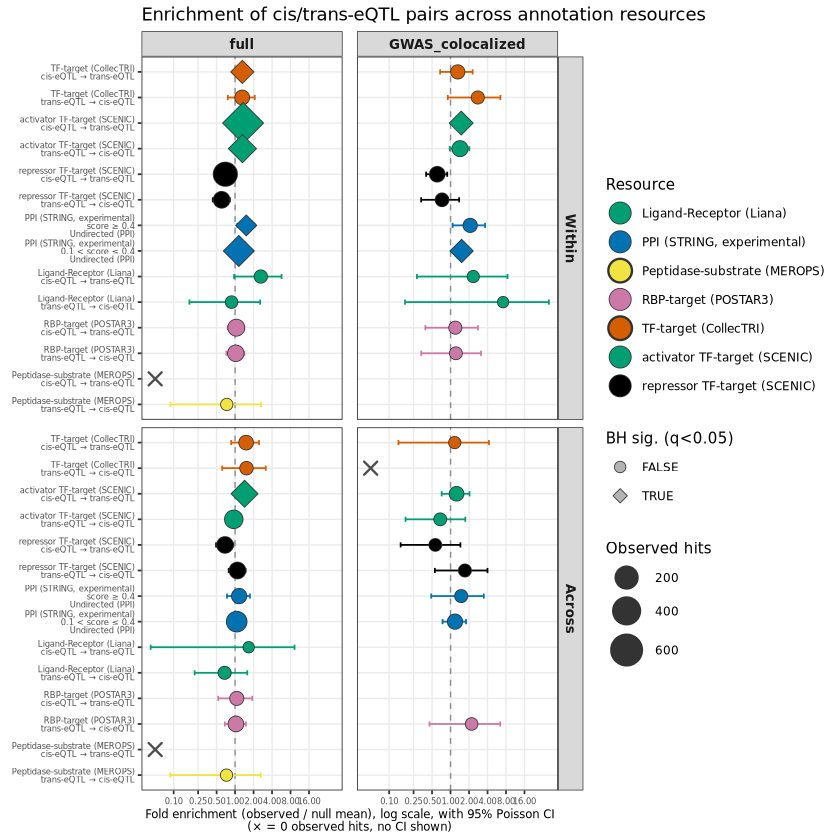

In [46]:
forest_plot_v7 <- ggplot(combined_results[is_untestable == FALSE],
                          aes(x = x_plot_final, y = row_label)) +
  geom_vline(xintercept = 1, linetype = "dashed", color = "grey40", alpha = 0.7) +
  geom_errorbar(aes(xmin = ci_low_plot, xmax = ci_high_plot, color = resource_display),
                orientation = "y", width = 0.2, linewidth = 0.5, na.rm = TRUE) +
  geom_point(
    data = combined_results[is_untestable == FALSE & is_zero_hit == FALSE],
    aes(size = observed_hits, fill = resource_display, shape = sig_BH_05),
    color = "grey20", stroke = 0.35
  ) +
  geom_point(
    data = combined_results[is_untestable == FALSE & is_zero_hit == TRUE],
    aes(fill = resource_display), shape = 4, size = 3, color = "grey30", stroke = 1
  ) +
  scale_shape_manual(values = c("TRUE" = 23, "FALSE" = 21), name = "BH sig. (q<0.05)") +
  scale_fill_manual(values = resource_colors_display, name = "Resource") +
  scale_color_manual(values = resource_colors_display, guide = "none") +
  scale_size_continuous(name = "Observed hits", range = c(3, 9)) +
  guides(
    fill  = guide_legend(override.aes = list(size = 6, shape = 21, colour = "grey20"), order = 1),
    shape = guide_legend(override.aes = list(size = 3, fill = "grey70"), order = 2)
  ) +
  scale_x_log10(breaks = c(0.1, 0.25, 0.5, 1, 2, 4, 8, 16),
                labels = scales::label_number(accuracy = 0.01)) +
  scale_y_discrete(limits = rev) +
  facet_grid(rows = vars(edge_type), cols = vars(graph_type), scales = "free_y", space = "free_y") +
  labs(
    x = "Fold enrichment (observed / null mean), log scale, with 95% Poisson CI\n(\u00d7 = 0 observed hits, no CI shown)",
    y = NULL,
    title = "Enrichment of cis/trans-eQTL pairs across annotation resources"
  ) +
  theme_bw(base_size = 9, base_family = "sans") +
  theme(
    axis.title.x = element_text(size = 7),
    axis.title.y = element_text(size = 7),
    axis.text.x  = element_text(size = 5),
    axis.text.y  = element_text(size = 5, lineheight = 0.8),
    axis.ticks   = element_line(linewidth = 0.5),
    panel.border = element_rect(linewidth = 0.5, fill = NA),
    strip.text = element_text(size = 8, face = "bold"),
    panel.grid.minor = element_blank(),
    panel.spacing.x = unit(0.6, "lines")
  )

print(forest_plot_v7)

In [47]:
ggsave(filename = paste0(graph_dir, "enrichment_forest_plot_v7.pdf"), plot = forest_plot_v7,
       device = "pdf", width = 12, height = 9)
ggsave(filename = paste0(graph_dir, "enrichment_forest_plot_v7.png"), plot = forest_plot_v7,
       device = "png", width = 12, height = 9, dpi = 300, bg="white")
ggsave(filename = paste0(graph_dir, "enrichment_forest_plot_v7.svg"), plot = forest_plot_v7,
       device = "svg", width = 12, height = 9)

cat("Saved to", graph_dir, "\n")
list.files(graph_dir, pattern = "v7")

Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'trans-eQTL → cis-eQTL' in 'mbcsToSbcs': -> substituted for → (U+2192)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'cis-eQTL → trans-eQTL' in 'mbcsToSbcs': -> substituted for → (U+2192)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'trans-eQTL → cis-eQTL' in 'mbcsToSbcs': -> substituted for → (U+2192)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'cis-eQTL → trans-eQTL' in 'mbcsToSbcs': -> substituted for → (U+2192)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'trans-eQTL → cis-eQTL' in 'mbcsToSbcs': -> substituted for → (U+2192)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'cis-eQTL → trans-eQTL' in 'mbcsToSbcs': -> substituted for → (U+2192)”
Warning message in grid.Call

Saved to /nfs/team151/mt19/overhaul_classification_factors_with_programs/graphs/ 


[1] "enrichment_forest_plot_v7.pdf" "enrichment_forest_plot_v7.png"
[3] "enrichment_forest_plot_v7.svg"

In [48]:
forest_plot_v8 <- forest_plot_v7  # same plot object, no theme/geometry changes needed

ggsave(filename = paste0(graph_dir, "enrichment_forest_plot_v8.pdf"), plot = forest_plot_v8,
       device = "pdf", width = 180, height = 130, units = "mm")
ggsave(filename = paste0(graph_dir, "enrichment_forest_plot_v8.png"), plot = forest_plot_v8,
       device = "png", width = 180, height = 130, units = "mm", dpi = 300, bg="white")
ggsave(filename = paste0(graph_dir, "enrichment_forest_plot_v8.svg"), plot = forest_plot_v8,
       device = "svg", width = 180, height = 130, units = "mm")

cat("Saved to", graph_dir, "\n")
list.files(graph_dir, pattern = "v8")

Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'trans-eQTL → cis-eQTL' in 'mbcsToSbcs': -> substituted for → (U+2192)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'cis-eQTL → trans-eQTL' in 'mbcsToSbcs': -> substituted for → (U+2192)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'trans-eQTL → cis-eQTL' in 'mbcsToSbcs': -> substituted for → (U+2192)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'cis-eQTL → trans-eQTL' in 'mbcsToSbcs': -> substituted for → (U+2192)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'trans-eQTL → cis-eQTL' in 'mbcsToSbcs': -> substituted for → (U+2192)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'cis-eQTL → trans-eQTL' in 'mbcsToSbcs': -> substituted for → (U+2192)”
Warning message in grid.Call

Saved to /nfs/team151/mt19/overhaul_classification_factors_with_programs/graphs/ 


[1] "enrichment_forest_plot_v8.pdf" "enrichment_forest_plot_v8.png"
[3] "enrichment_forest_plot_v8.svg"

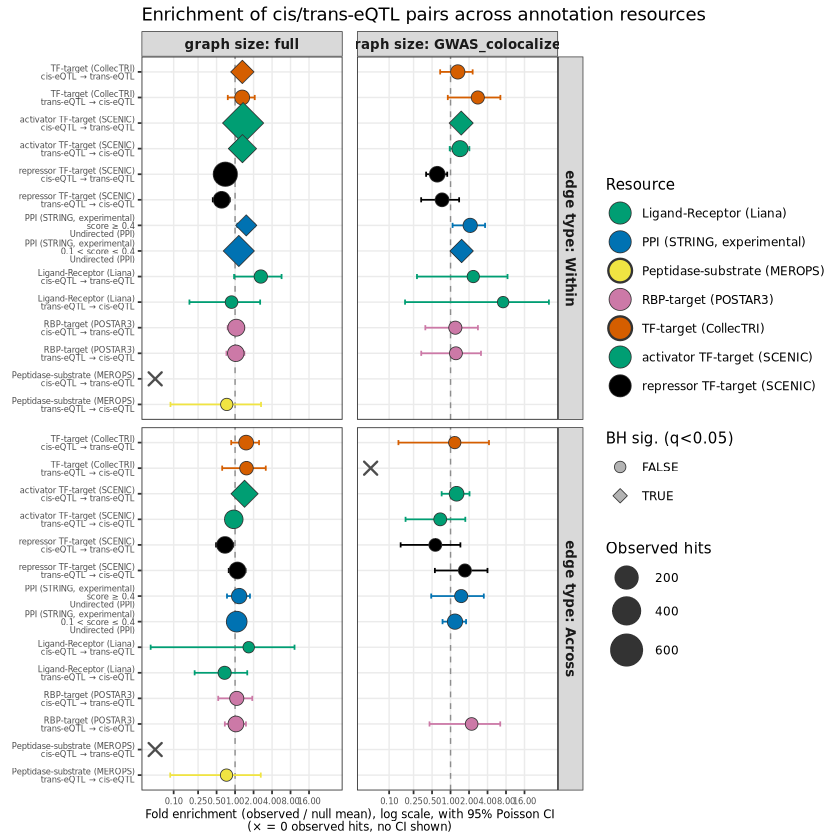

In [49]:
forest_plot_v9 <- ggplot(combined_results[is_untestable == FALSE],
                          aes(x = x_plot_final, y = row_label)) +
  geom_vline(xintercept = 1, linetype = "dashed", color = "grey40", alpha = 0.7) +
  geom_errorbar(aes(xmin = ci_low_plot, xmax = ci_high_plot, color = resource_display),
                orientation = "y", width = 0.2, linewidth = 0.5, na.rm = TRUE) +
  geom_point(
    data = combined_results[is_untestable == FALSE & is_zero_hit == FALSE],
    aes(size = observed_hits, fill = resource_display, shape = sig_BH_05),
    color = "grey20", stroke = 0.35
  ) +
  geom_point(
    data = combined_results[is_untestable == FALSE & is_zero_hit == TRUE],
    aes(fill = resource_display), shape = 4, size = 3, color = "grey30", stroke = 1
  ) +
  scale_shape_manual(values = c("TRUE" = 23, "FALSE" = 21), name = "BH sig. (q<0.05)") +
  scale_fill_manual(values = resource_colors_display, name = "Resource") +
  scale_color_manual(values = resource_colors_display, guide = "none") +
  scale_size_continuous(name = "Observed hits", range = c(3, 9)) +
  guides(
    fill  = guide_legend(override.aes = list(size = 6, shape = 21, colour = "grey20"), order = 1),
    shape = guide_legend(override.aes = list(size = 3, fill = "grey70"), order = 2)
  ) +
  scale_x_log10(breaks = c(0.1, 0.25, 0.5, 1, 2, 4, 8, 16),
                labels = scales::label_number(accuracy = 0.01)) +
  scale_y_discrete(limits = rev) +
  facet_grid(
    rows = vars(edge_type), cols = vars(graph_type),
    scales = "free_y", space = "free_y",
    labeller = labeller(
      edge_type  = as_labeller(function(x) paste("edge type:", x)),
      graph_type = as_labeller(function(x) paste("graph size:", x))
    )
  ) +
  labs(
    x = "Fold enrichment (observed / null mean), log scale, with 95% Poisson CI\n(\u00d7 = 0 observed hits, no CI shown)",
    y = NULL,
    title = "Enrichment of cis/trans-eQTL pairs across annotation resources"
  ) +
  theme_bw(base_size = 9, base_family = "sans") +
  theme(
    axis.title.x = element_text(size = 7),
    axis.title.y = element_text(size = 7),
    axis.text.x  = element_text(size = 5),
    axis.text.y  = element_text(size = 5, lineheight = 0.8),
    axis.ticks   = element_line(linewidth = 0.5),
    panel.border = element_rect(linewidth = 0.5, fill = NA),
    strip.text = element_text(size = 8, face = "bold"),
    panel.grid.minor = element_blank(),
    panel.spacing.x = unit(0.6, "lines")
  )

print(forest_plot_v9)

In [50]:
ggsave(filename = paste0(graph_dir, "enrichment_forest_plot_v9.pdf"), plot = forest_plot_v9,
       device = "pdf", width = 180, height = 130, units = "mm")
ggsave(filename = paste0(graph_dir, "enrichment_forest_plot_v9.png"), plot = forest_plot_v9,
       device = "png", width = 180, height = 130, units = "mm", dpi = 300, bg="white")
ggsave(filename = paste0(graph_dir, "enrichment_forest_plot_v9.svg"), plot = forest_plot_v9,
       device = "svg", width = 180, height = 130, units = "mm")

cat("Saved to", graph_dir, "\n")
list.files(graph_dir, pattern = "v9")

Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'trans-eQTL → cis-eQTL' in 'mbcsToSbcs': -> substituted for → (U+2192)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'cis-eQTL → trans-eQTL' in 'mbcsToSbcs': -> substituted for → (U+2192)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'trans-eQTL → cis-eQTL' in 'mbcsToSbcs': -> substituted for → (U+2192)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'cis-eQTL → trans-eQTL' in 'mbcsToSbcs': -> substituted for → (U+2192)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'trans-eQTL → cis-eQTL' in 'mbcsToSbcs': -> substituted for → (U+2192)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'cis-eQTL → trans-eQTL' in 'mbcsToSbcs': -> substituted for → (U+2192)”
Warning message in grid.Call

Saved to /nfs/team151/mt19/overhaul_classification_factors_with_programs/graphs/ 


[1] "enrichment_forest_plot_v9.pdf" "enrichment_forest_plot_v9.png"
[3] "enrichment_forest_plot_v9.svg"

# SAVE object for replotting

In [51]:
# --- Save combined_results in its fully processed form for future replotting ---
# NOTE: combined_results now has factor-leveled columns (row_label, edge_type,
# graph_type) whose ORDER encodes the plotting logic (resource-grouped, etc.).
# .rds preserves factor levels/order exactly; .tsv does NOT (factors get
# written as plain strings, losing the encoded order) - so .rds is the
# reload-for-replotting copy, .tsv is for inspection/sharing only.

save_path_rds <- "/nfs/team151/mt19/overhaul_classification_factors_with_programs/combined_results_enrichment.rds"
save_path_tsv <- "/nfs/team151/mt19/overhaul_classification_factors_with_programs/combined_results_enrichment.tsv"

saveRDS(combined_results, save_path_rds)
fwrite(combined_results, save_path_tsv, sep = "\t")

cat("Saved", nrow(combined_results), "rows,", ncol(combined_results), "columns\n")
print(colnames(combined_results))

# --- Verify before trusting: reload and spot-check row count, key stats, and factor level order ---
check <- readRDS(save_path_rds)
stopifnot(nrow(check) == nrow(combined_results))
stopifnot(identical(levels(check$row_label), levels(combined_results$row_label)))
stopifnot(sum(check$sig_BH_05, na.rm = TRUE) == sum(combined_results$sig_BH_05, na.rm = TRUE))
cat("Reload check passed: row count, row_label factor order, and BH-significant count all match.\n")

Saved 56 rows, 31 columns
 [1] "analysis"           "direction"          "condition"         
 [4] "observed_hits"      "null_mean"          "null_sd"           
 [7] "z_score"            "p_enrichment"       "is_untestable"     
[10] "resource_name"      "stringency_label"   "eqtl_condition"    
[13] "edge_type"          "graph_type"         "neg_log10_p"       
[16] "fold_enrichment"    "x_plot"             "resource_display"  
[19] "direction_display"  "p_adj_BH"           "p_adj_bonferroni"  
[22] "sig_BH_05"          "sig_bonferroni_05"  "fold_ci_low"       
[25] "fold_ci_high"       "row_label"          "stringency_display"
[28] "is_zero_hit"        "x_plot_final"       "ci_low_plot"       
[31] "ci_high_plot"      
Reload check passed: row count, row_label factor order, and BH-significant count all match.


In [52]:
print(combined_results[resource_display == "Ligand-Receptor (Liana)" & edge_type == "Within" & graph_type == "full",
  .(direction, observed_hits, null_mean, p_enrichment, p_adj_BH, sig_BH_05)])

cat("Total testable tests (m) now:", sum(!combined_results$is_untestable), "\n")

   direction observed_hits null_mean p_enrichment   p_adj_BH sig_BH_05
      <char>         <int>     <num>        <num>      <num>    <lgcl>
1:   forward             6    2.2851   0.01149885 0.05634437     FALSE
2:   reverse             3    3.4243   0.69943006 0.97920208     FALSE
Total testable tests (m) now: 49 


# Coverage of edge annotation analysis

## Annotated graph

In [53]:
whole_eqtl_annotated <- readRDS(file = "/nfs/team151/mt19/overhaul_classification_factors_with_programs/whole_eqtl_annotated.rds")
cat("whole_eqtl_annotated\n")
cat(str(whole_eqtl_annotated))
cat("\n")


whole_eqtl_annotated
Classes ‘data.table’ and 'data.frame':	305496 obs. of  14 variables:
 $ Source_trait         : chr  "T_CD4_naive:ENSG00000103145" "T_CD4_naive:ENSG00000103145" "T_CD4_naive:ENSG00000103145" "T_CD4_naive:ENSG00000103145" ...
 $ Target_trait         : chr  "T_CD4_naive:ENSG00000185885" "T_CD4_naive:ENSG00000117984" "T_CD4_naive:ENSG00000175390" "T_CD4_naive:ENSG00000090554" ...
 $ program              : chr  "D_Factor36" "D_Factor36" "D_Factor36" "D_Factor36" ...
 $ Source_cell          : chr  "T_CD4_naive" "T_CD4_naive" "T_CD4_naive" "T_CD4_naive" ...
 $ Source_gene          : chr  "ENSG00000103145" "ENSG00000103145" "ENSG00000103145" "ENSG00000103145" ...
 $ Target_cell          : chr  "T_CD4_naive" "T_CD4_naive" "T_CD4_naive" "T_CD4_naive" ...
 $ Target_gene          : chr  "ENSG00000185885" "ENSG00000117984" "ENSG00000175390" "ENSG00000090554" ...
 $ Source_module        : chr  "M_10" "M_10" "M_10" "M_10" ...
 $ edge.type            : chr  "Within" "Within" "With

## Edge-level coverage (non-stacked, log scale)

Edges with >=1 annotation: 9348 / 305496 (3.06%)
                                   label             resource_display edge_type
                                  <fctr>                       <char>    <fctr>
 1:          Source_TF_activator->Target activator TF-target (SCENIC)    Within
 2: PPI (STRING_experimental >=0.1 <0.4)   PPI (STRING, experimental)    Within
 3:          Target_TF_activator->Source activator TF-target (SCENIC)    Within
 4:          Source_TF_repressor->Target repressor TF-target (SCENIC)    Within
 5:          Target_TF_repressor->Source repressor TF-target (SCENIC)    Within
 6:                    Source_TF->Target        TF-target (CollecTRI)    Within
 7:                   Target_RBP->Source         RBP-target (POSTAR3)    Within
 8:      PPI (STRING_experimental >=0.4)   PPI (STRING, experimental)    Within
 9:       Target_Ligand->Source_Receptor      Ligand-Receptor (Liana)    Within
10:                   Source_RBP->Target         RBP-target (POSTAR3)  

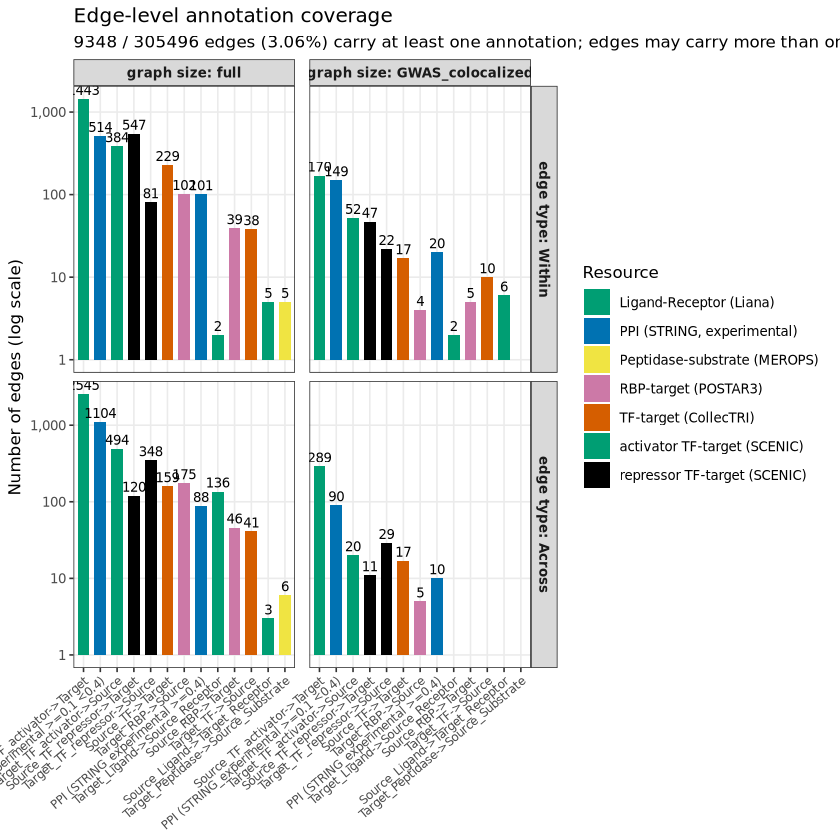

In [58]:
# --- Rebuild edge-level (label, resource) pairs from the ";"-joined strings, keeping lockstep pairing ---
rows <- whole_eqtl_annotated[!is.na(edge_role)]

# Derive facet columns on the ROW level first (same convention as forest_plot_v9)
rows[, edge_type  := factor(edge.type, levels = c("Within", "Across"))]
rows[, graph_type := factor(ifelse(GWAS_colocalized, "GWAS_colocalized", "full"),
                             levels = c("full", "GWAS_colocalized"))]

role_split     <- strsplit(rows$edge_role, ";")
resource_split <- strsplit(rows$edge_resource, ";")
stopifnot(all(lengths(role_split) == lengths(resource_split)))  # confirms pairing is intact before unlisting

n_per_row <- lengths(role_split)  # how many (label,resource) pairs each row expands to

edge_long <- data.table(
  label        = unlist(role_split),
  resource_tag = unlist(resource_split),
  edge_type    = rep(rows$edge_type, n_per_row),   # repeat row-level facet vars to match the unlisted length
  graph_type   = rep(rows$graph_type, n_per_row)
)

# Strip stringency-detail suffix e.g. "CollecTRI (>=2 CollecTRI sub-resources)" -> "CollecTRI"
edge_long[, resource_base := sub(" \\(.*\\)$", "", resource_tag)]
stopifnot(all(edge_long$resource_base %in% names(resource_display_labels)))
edge_long[, resource_display := resource_display_labels[resource_base]]

# --- Aggregate counts per (label, resource, edge_type, graph_type) ---
edge_label_resource_dt <- edge_long[, .N, by = .(label, resource_display, edge_type, graph_type)]

# Order labels by TOTAL count across resources AND facets (global ordering, consistent across panels)
label_totals <- edge_long[, .N, by = label][order(-N)]
edge_label_resource_dt[, label := factor(label, levels = label_totals$label)]

# Per-facet totals for the geom_text labels (top-of-stack count within each Within/Across x full/GWAS panel)
label_totals_facet <- edge_long[, .N, by = .(label, edge_type, graph_type)]
label_totals_facet[, label := factor(label, levels = label_totals$label)]

n_any_annotated   <- sum(whole_eqtl_annotated$n_edge_roles > 0)
pct_any_annotated <- round(100 * n_any_annotated / n_edges_total, 2)
cat(sprintf("Edges with >=1 annotation: %d / %d (%.2f%%)\n", n_any_annotated, n_edges_total, pct_any_annotated))
print(edge_label_resource_dt[order(edge_type, graph_type, label, -N)])

# --- Plot: stacked bars by resource, faceted Within/Across (rows) x full/GWAS (cols) ---
p_edge_coverage <- ggplot(edge_label_resource_dt, aes(x = label, y = N, fill = resource_display)) +
  geom_col(width = 0.7) +
  geom_text(
    data = label_totals_facet,
    aes(x = label, y = N, label = N),
    inherit.aes = FALSE, vjust = -0.4, size = 2.8
  ) +
  scale_y_log10(labels = scales::label_comma()) +
  scale_fill_manual(values = resource_colors_display, name = "Resource") +
  facet_grid(
    rows = vars(edge_type), cols = vars(graph_type),
    scales = "free_y", space = "free_x",
    labeller = labeller(
      edge_type  = as_labeller(function(x) paste("edge type:", x)),
      graph_type = as_labeller(function(x) paste("graph size:", x))
    )
  ) +
  labs(
    title = "Edge-level annotation coverage",
    subtitle = paste0(n_any_annotated, " / ", n_edges_total, " edges (", pct_any_annotated,
                       "%) carry at least one annotation; edges may carry more than one label"),
    x = NULL, y = "Number of edges (log scale)"
  ) +
  theme_bw(base_size = 10) +
  theme(axis.text.x = element_text(angle = 40, hjust = 1, size = 7),
        strip.text = element_text(size = 8, face = "bold"),
        panel.grid.minor = element_blank(),
        panel.spacing.x = unit(0.6, "lines"))
print(p_edge_coverage)

In [61]:
coverage_dir <- "/nfs/team151/mt19/overhaul_classification_factors_with_programs/coverage_analysis/"
dir.create(coverage_dir, recursive = TRUE, showWarnings = FALSE)



cat("Created:", coverage_dir, "\n")

Created: /nfs/team151/mt19/overhaul_classification_factors_with_programs/coverage_analysis/ 


In [64]:
ggsave(paste0(coverage_dir, "edge_level_coverage.pdf"), p_edge_coverage, width = 8, height = 6)
ggsave(paste0(coverage_dir, "edge_level_coverage.png"), p_edge_coverage, width = 8, height = 6, dpi = 200)
ggsave(paste0(coverage_dir, "edge_level_coverage.svg"), p_edge_coverage, width = 8, height = 6)
saveRDS(edge_label_resource_dt, paste0(coverage_dir, "edge_label_resource_dt.rds"))

## Gene-pair-collapsed Fisher test:

In [83]:
# --- Gene-pair-collapsed Fisher test: one row per unique (Source_gene, Target_gene) pair
#     within each edge_type category, rather than one row per eQTL edge instance.
#     This is the correct denominator/numerator for a claim about DISTINCT gene relationships,
#     as opposed to the edge-level Fisher test, which over-counts a gene pair once per
#     recurring instance (different cell types/programs) and inflates apparent sample size.

run_collapsed_fisher_for_label <- function(label, resource_base, gene_universe, dt) {
  assessable <- dt[graph_type_f == "full" &
                    Source_gene %in% gene_universe & Target_gene %in% gene_universe]
  if (nrow(assessable) == 0 || uniqueN(assessable$edge_type_f) < 2) {
    return(data.table(resource = resource_base, label = label, status = "insufficient_data"))
  }

  assessable[, has_label := !is.na(edge_role) & grepl(label, edge_role, fixed = TRUE)]

  # Collapse: one row per (Source_gene, Target_gene, edge_type) - a pair is "annotated" in that
  # edge_type category if it carries the label in AT LEAST ONE of its recurring instances there.
  collapsed <- unique(assessable[, .(Source_gene, Target_gene, edge_type_f, has_label)])
  collapsed <- collapsed[, .(has_label = any(has_label)), by = .(Source_gene, Target_gene, edge_type_f)]

  n_pairs_within <- uniqueN(collapsed[edge_type_f == "Within", .(Source_gene, Target_gene)])
  n_pairs_across <- uniqueN(collapsed[edge_type_f == "Across", .(Source_gene, Target_gene)])

  tab <- table(collapsed$edge_type_f, collapsed$has_label)
  if (!all(dim(tab) == c(2, 2))) {
    return(data.table(resource = resource_base, label = label, status = "degenerate_table_after_collapse",
                       n_pairs_within = n_pairs_within, n_pairs_across = n_pairs_across))
  }

  ft <- fisher.test(tab)

  data.table(
    resource            = resource_base,
    label               = label,
    status              = "ok",
    n_pairs_within      = n_pairs_within,
    n_pairs_across      = n_pairs_across,
    pairs_annot_within  = tab["Within", "TRUE"],
    pairs_annot_across  = tab["Across", "TRUE"],
    odds_ratio          = unname(ft$estimate),
    ci_low              = ft$conf.int[1],
    ci_high             = ft$conf.int[2],
    p_value             = ft$p.value
  )
}

collapsed_fisher_results <- rbindlist(lapply(seq_len(nrow(label_resource_map)), function(i) {
  lbl <- label_resource_map$label[i]; res <- label_resource_map$resource_base[i]
  gu  <- resource_gene_universes[[res]]
  if (is.null(gu)) return(data.table(resource = res, label = lbl, status = "no_gene_universe"))
  run_collapsed_fisher_for_label(lbl, res, gu, whole_eqtl_annotated)
}), fill = TRUE)

collapsed_fisher_results[status == "ok", p_adj_BH := p.adjust(p_value, method = "BH")]
collapsed_fisher_results[status == "ok", sig_BH_05 := p_adj_BH < 0.05]

print(collapsed_fisher_results[order(p_value)])

                                 resource                                label
                                   <char>                               <char>
 1: SCENIC_regulon_activator_same_dataset          Source_TF_activator->Target
 2: SCENIC_regulon_repressor_same_dataset          Source_TF_repressor->Target
 3:                             CollecTRI                    Source_TF->Target
 4: SCENIC_regulon_activator_same_dataset          Target_TF_activator->Source
 5: SCENIC_regulon_repressor_same_dataset          Target_TF_repressor->Source
 6:                               POSTAR3                   Source_RBP->Target
 7:                                 Liana       Target_Ligand->Source_Receptor
 8:                                 Liana       Source_Ligand->Target_Receptor
 9:                   STRING_experimental PPI (STRING_experimental >=0.1 <0.4)
10:                               POSTAR3                   Target_RBP->Source
11:                   STRING_experimental      PPI (

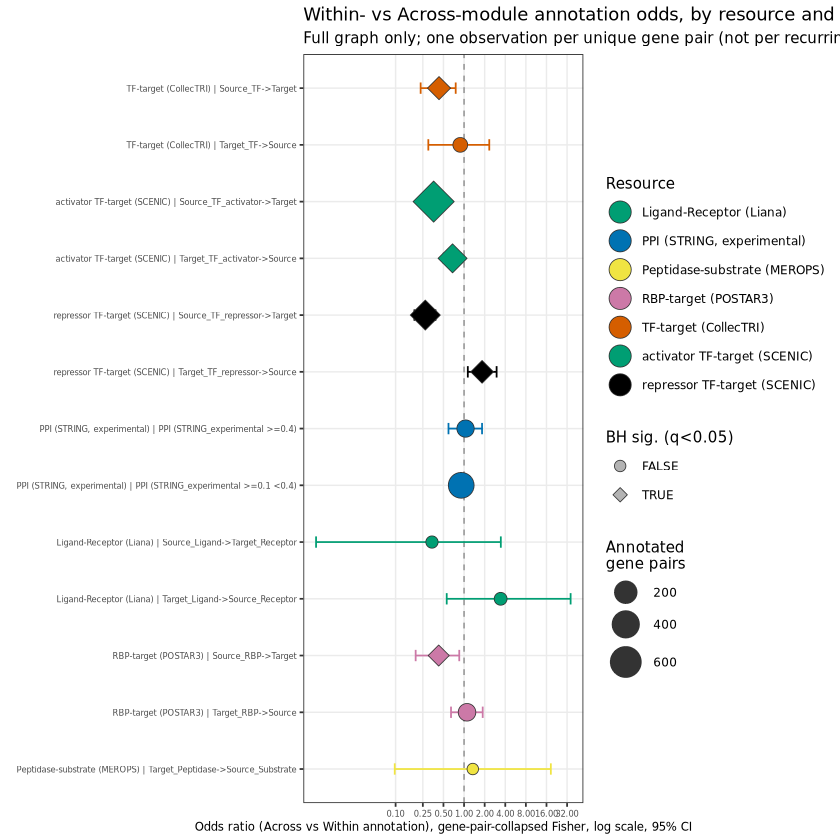

In [85]:
# --- Explicit y-axis ordering, matching forest_plot_v9's resource-block layout ---
# (resource block order: CollecTRI, SCENIC activator, SCENIC repressor, STRING/PPI, Liana, POSTAR3, MEROPS;
#  within each block: forward/Source-> orientation before reverse/Target-> orientation)

label_order <- c(
  "Source_TF->Target",                     # CollecTRI forward
  "Target_TF->Source",                     # CollecTRI reverse
  "Source_TF_activator->Target",           # SCENIC activator forward
  "Target_TF_activator->Source",           # SCENIC activator reverse
  "Source_TF_repressor->Target",           # SCENIC repressor forward
  "Target_TF_repressor->Source",           # SCENIC repressor reverse
  "PPI (STRING_experimental >=0.4)",       # STRING strict
  "PPI (STRING_experimental >=0.1 <0.4)",  # STRING lenient band
  "Source_Ligand->Target_Receptor",        # Liana forward
  "Target_Ligand->Source_Receptor",        # Liana reverse
  "Source_RBP->Target",                    # POSTAR3 forward
  "Target_RBP->Source",                    # POSTAR3 reverse
  "Source_Peptidase->Target_Substrate",    # MEROPS forward
  "Target_Peptidase->Source_Substrate"     # MEROPS reverse
)

# Build row_label using the SAME label_order sequence, keeping only rows present in plot_dt
plot_dt[, label := factor(label, levels = label_order)]
plot_dt <- plot_dt[order(label)]
plot_dt[, row_label := factor(paste(resource_display, label, sep = " | "),
                               levels = paste(resource_display, label, sep = " | ")[order(label)])]

# --- Forest plot, same style as before, now with explicit ordering instead of scale_y_discrete(limits = rev) ---
forest_plot_collapsed <- ggplot(plot_dt, aes(x = odds_ratio, y = row_label)) +
  geom_vline(xintercept = 1, linetype = "dashed", color = "grey40", alpha = 0.7) +
  geom_errorbar(aes(xmin = ci_low, xmax = ci_high, color = resource_display),
                orientation = "y", width = 0.2, linewidth = 0.5, na.rm = TRUE) +
  geom_point(aes(size = total_annot_pairs, fill = resource_display, shape = sig_BH_05),
             color = "grey20", stroke = 0.35) +
  scale_shape_manual(values = c("TRUE" = 23, "FALSE" = 21), name = "BH sig. (q<0.05)") +
  scale_fill_manual(values = resource_colors_display, name = "Resource") +
  scale_color_manual(values = resource_colors_display, guide = "none") +
  scale_size_continuous(name = "Annotated\ngene pairs", range = c(3, 9)) +
  guides(
    fill  = guide_legend(override.aes = list(size = 6, shape = 21, colour = "grey20"), order = 1),
    shape = guide_legend(override.aes = list(size = 3, fill = "grey70"), order = 2)
  ) +
  scale_x_log10(breaks = c(0.1, 0.25, 0.5, 1, 2, 4, 8, 16, 32),
                labels = scales::label_number(accuracy = 0.01)) +
  scale_y_discrete(limits = rev(levels(plot_dt$row_label))) +
  labs(
    x = "Odds ratio (Across vs Within annotation), gene-pair-collapsed Fisher, log scale, 95% CI",
    y = NULL,
    title = "Within- vs Across-module annotation odds, by resource and orientation",
    subtitle = "Full graph only; one observation per unique gene pair (not per recurring eQTL edge)"
  ) +
  theme_bw(base_size = 9, base_family = "sans") +
  theme(
    axis.title.x = element_text(size = 7),
    axis.title.y = element_text(size = 7),
    axis.text.x  = element_text(size = 5),
    axis.text.y  = element_text(size = 5, lineheight = 0.8),
    axis.ticks   = element_line(linewidth = 0.5),
    panel.border = element_rect(linewidth = 0.5, fill = NA),
    strip.text = element_text(size = 8, face = "bold"),
    panel.grid.minor = element_blank()
  )
print(forest_plot_collapsed)

In [86]:
ggsave(paste0(coverage_dir, "forest_plot_collapsed_fisher.pdf"), forest_plot_collapsed, width = 8, height = 6)
ggsave(paste0(coverage_dir, "forest_plot_collapsed_fisher.png"), forest_plot_collapsed, width = 8, height = 6, dpi = 200)
ggsave(paste0(coverage_dir, "forest_plot_collapsed_fisher.svg"), forest_plot_collapsed, width = 8, height = 6)
saveRDS(plot_dt, paste0(coverage_dir, "forest_plot_collapsed_fisher_data.rds"))

## UpsetR plot

Unique annotated gene pairs (full graph): 1651 
Resources included: CollecTRI, Liana, MEROPS, POSTAR3, SCENIC_regulon_activator_same_dataset, SCENIC_regulon_repressor_same_dataset, STRING_experimental 


Warning message:
“`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.
ℹ The deprecated feature was likely used in the UpSetR package.
  Please report the issue at <https://github.com/hms-dbmi/UpSetR/issues>.”
Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.
ℹ The deprecated feature was likely used in the UpSetR package.
  Please report the issue at <https://github.com/hms-dbmi/UpSetR/issues>.”
Warning message:
“The `size` argument of `element_line()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.
ℹ The deprecated feature was likely used in the UpSetR package.
  Please report the issue at <https://github.com/hms-dbmi/UpSetR/issues>.”


agg_record_3ddfa73d0011fc 
                        2

agg_record_3ddfa73d0011fc 
                        2

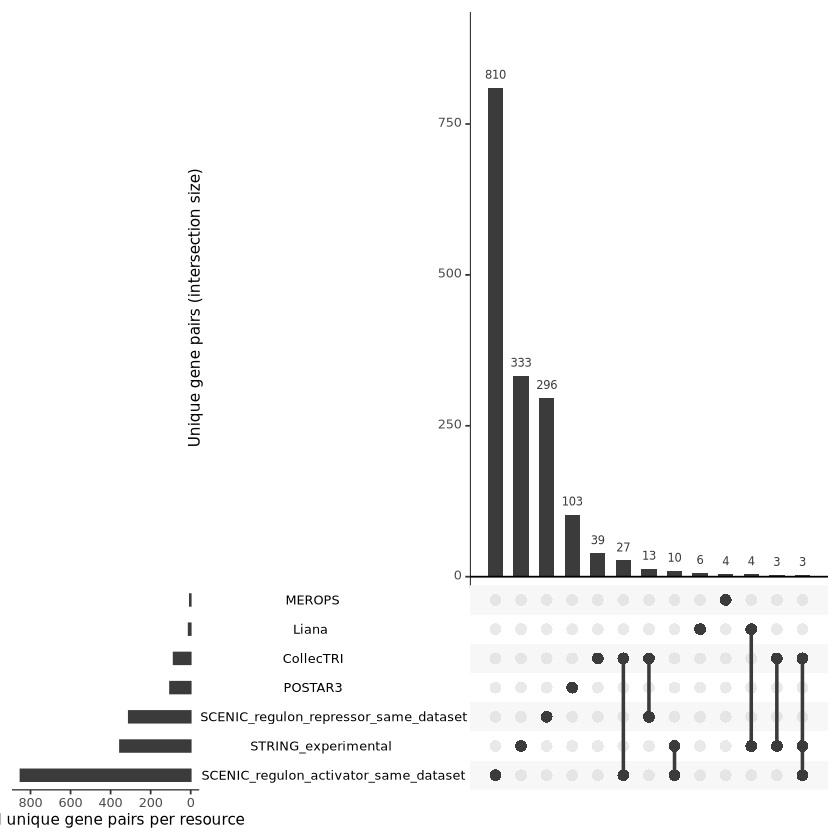

In [89]:

# --- Build unique-gene-pair x resource membership matrix, full graph only ---
full_rows <- whole_eqtl_annotated[graph_type_f == "full" & !is.na(edge_resource)]

resource_split_full <- strsplit(full_rows$edge_resource, ";")
gene_pair_resource_long <- data.table(
  Source_gene  = rep(full_rows$Source_gene, lengths(resource_split_full)),
  Target_gene  = rep(full_rows$Target_gene, lengths(resource_split_full)),
  resource_tag = unlist(resource_split_full)
)
gene_pair_resource_long[, resource_base := sub(" \\(.*\\)$", "", resource_tag)]

# One row per (gene pair, resource) - a pair "has" a resource if ANY of its recurring
# eQTL-edge instances carries it, in EITHER direction (forward/reverse collapsed here,
# since this is a resource-level overlap question, not an orientation question)
gene_pair_membership <- unique(gene_pair_resource_long[, .(Source_gene, Target_gene, resource_base)])
gene_pair_membership[, present := 1L]

upset_wide <- dcast(gene_pair_membership, Source_gene + Target_gene ~ resource_base,
                     value.var = "present", fill = 0L)

resource_cols <- setdiff(names(upset_wide), c("Source_gene", "Target_gene"))
cat("Unique annotated gene pairs (full graph):", nrow(upset_wide), "\n")
cat("Resources included:", paste(resource_cols, collapse = ", "), "\n")

# --- Save the underlying data table for future replotting, same convention as before ---
saveRDS(upset_wide, paste0(coverage_dir, "gene_pair_resource_upset_data.rds"))

# --- UpSet plot ---
upset_plot <- upset(
  as.data.frame(upset_wide[, ..resource_cols]),
  sets = resource_cols,
  order.by = "freq",
  nsets = length(resource_cols),
  mainbar.y.label = "Unique gene pairs (intersection size)",
  sets.x.label = "Total unique gene pairs per resource",
  text.scale = 1.1,
  point.size = 3, line.size = 1
)
print(upset_plot)

pdf(paste0(coverage_dir, "gene_pair_resource_upset.pdf"), width = 10, height = 6)
print(upset_plot)
dev.off()

png(paste0(coverage_dir, "gene_pair_resource_upset.png"), width = 10, height = 6, units = "in", res = 200)
print(upset_plot)
dev.off()